# Data Preprocessing

# Movie-Movie Connections

Filter data

In [ ]:
#filter ratings<min_rating
#for limit 3 & 4

import csv

def filter_ratings(input_file, output_file, min_rating=4.0):
    # Store filtered rows
    filtered_rows = []

    with open(input_file, 'r') as infile:
        reader = csv.DictReader(infile)
        # Verify expected columns
        if 'Weight' not in reader.fieldnames:
            raise ValueError("No 'rating' column found in the input file.")

        # Keep header
        header = reader.fieldnames
        filtered_rows.append(header)

        # Filter rows
        for row in reader:
            try:
                rating = float(row['Weight'])  # Convert rating to float
                if rating >= min_rating:
                    filtered_rows.append([row[field] for field in header])
            except ValueError:
                print(f"Skipping invalid rating: {row['Weight']} in row {row}")

    # Write filtered data to new file
    with open(output_file, 'w', newline='') as outfile:
        writer = csv.writer(outfile)
        writer.writerows(filtered_rows)

    print(f"Filtered ratings saved to {output_file}. Rows kept: {len(filtered_rows) - 1}")

# Usage
input_file = 'ratings_2.csv'
output_file = 'filtered_ratings.csv'
filter_ratings(input_file, output_file, min_rating=4.0)

TypeError: float() argument must be a string or a real number, not 'NoneType'

Projection of movies

In [ ]:
import csv
from collections import defaultdict
from itertools import combinations

# Minimum number of shared users required for an edge
MIN_SHARED_USERS = 25

# Step 1: Parse the user-movie data and group movies by user
def load_user_movie_data(file_path, user_col='Source', movie_col='Target'):
    user_to_movies = defaultdict(list)
    unique_movies = set()
    with open(file_path, 'r', encoding='utf-8-sig') as file:
        reader = csv.DictReader(file)
        if user_col not in reader.fieldnames or movie_col not in reader.fieldnames:
            raise KeyError(f"Columns '{user_col}' or '{movie_col}' not found in {file_path}. Available columns: {reader.fieldnames}")
        for row in reader:
            user = row[user_col]
            movie = row[movie_col]
            user_to_movies[user].append(movie)
            unique_movies.add(movie)
    print(f"Number of unique movies: {len(unique_movies)}")
    return user_to_movies

# Step 2: Create the movie-movie projection with a minimum threshold
def create_movie_projection(user_to_movies, min_shared_users=MIN_SHARED_USERS):
    movie_pairs = defaultdict(int)
    for user, movies in user_to_movies.items():
        movies = sorted(set(movies))  # Remove duplicates per user
        for movie1, movie2 in combinations(movies, 2):
            movie_pairs[(movie1, movie2)] += 1

    # Filter pairs with at least min_shared_users
    filtered_pairs = {pair: count for pair, count in movie_pairs.items() if count >= min_shared_users}
    return filtered_pairs

# Step 3: Write the projection to a CSV file and check for multi-edges
def write_projection_to_csv(movie_pairs, output_file):
    seen_pairs = set()
    with open(output_file, 'w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(['Source', 'Target', 'Weight'])
        for (movie1, movie2), weight in movie_pairs.items():
            pair = (movie1, movie2)
            if pair in seen_pairs:
                print(f"Warning: Duplicate edge detected: {movie1},{movie2}")
            else:
                seen_pairs.add(pair)
                writer.writerow([movie1, movie2, weight])
    print(f"Number of unique edges in projection (with >= {MIN_SHARED_USERS} shared users): {len(seen_pairs)}")

# Main function
def main(input_file, output_file, user_col='Source', movie_col='Target'):
    print("Loading user-movie data...")
    user_to_movies = load_user_movie_data(input_file, user_col, movie_col)

    print("Creating movie-movie projection...")
    movie_pairs = create_movie_projection(user_to_movies)

    print("Writing projection to CSV...")
    write_projection_to_csv(movie_pairs, output_file)
    print(f"Projection complete. Output saved to {output_file}")

# Example usage
if __name__ == "__main__":
    input_file = 'ratings_2.csv'  # Your input file path
    output_file = 'ratings_projection.csv'     # Output file path

    user_column = 'Source'  # Matches your file with BOM
    movie_column = 'Target'       # Matches your file

    main(input_file, output_file, user_col=user_column, movie_col=movie_column)

Loading user-movie data...
Number of unique movies: 8452
Creating movie-movie projection...
Writing projection to CSV...
Number of unique edges in projection (with >= 25 shared users): 35720
Projection complete. Output saved to ratings_projection.csv


Extract unique movies

In [ ]:
import csv

def write_unique_movies_to_csv(input_file, output_file):
    unique_movies = set()
    with open(input_file, 'r') as infile:
        reader = csv.DictReader(infile)
        for row in reader:
            unique_movies.add(row['Source'])  # Add Source movie ID
            unique_movies.add(row['Target'])  # Add Target movie ID

    with open(output_file, 'w', newline='') as outfile:
        writer = csv.writer(outfile)
        writer.writerow(['Id'])  # Write header
        for movie in sorted(unique_movies, key=int):  # Sort as integers
            writer.writerow([movie])

# Usage
input_file = 'ratings_projection.csv'
output_file = 'filtered_movies.csv'
write_unique_movies_to_csv(input_file, output_file)
print(f"Unique movies saved to {output_file}")

Unique movies saved to filtered_movies.csv


Analyzing communties based on modularity class

In [2]:
import pandas as pd

# Load the nodes with community assignments from Gephi
nodes_df = pd.read_csv('community_Detection.csv')
# Remove 'm' prefix from movie IDs to match movies.csv
nodes_df['movieId'] = nodes_df['Id']

# Load the movies data with genres
movies_df = pd.read_csv('updated_movies_with_year.csv')

# Merge the two dataframes on movieId
merged_df = pd.merge(nodes_df, movies_df, on='movieId', how='inner')

# Save the merged data for reference
merged_df.to_csv('movies_with_communities.csv', index=False)

# Display the first few rows to verify
print(merged_df[['movieId', 'title', 'year', 'modularity_Class', 'stat_inf_Class']].head())

   movieId                                       title    year  \
0        1                            Toy Story (1995)  1995.0   
1     1032                  Alice in Wonderland (1951)  1951.0   
2     1073  Willy Wonka & the Chocolate Factory (1971)  1971.0   
3     1080         Monty Python's Life of Brian (1979)  1979.0   
4     1089                       Reservoir Dogs (1992)  1992.0   

   modularity_Class  stat_inf_Class  
0                 2             186  
1                 2              50  
2                 2              16  
3                 0             166  
4                 0              65  


Extracting genres

In [3]:
from collections import Counter

# Function to count release years per community
def analyze_years_per_community(df):
    # Dictionary to store year counts per community
    community_years = {}

    # Iterate over each community
    for community_id in df['modularity_Class'].unique():
        # Filter movies in this community
        community_movies = df[df['modularity_Class'] == community_id]
        # Extract valid years
        year_list = []
        for year in community_movies['year']:
            if pd.notna(year):
                try:
                    year_list.append(int(year))
                except ValueError:
                    pass  # Skip non-integer years if any
        # Count year occurrences
        year_counts = Counter(year_list)
        community_years[community_id] = year_counts

    return community_years

# Run the analysis
community_years = analyze_years_per_community(merged_df)

# Print results
for community_id, year_counts in community_years.items():
    print(f"Community {community_id} ({len(merged_df[merged_df['modularity_Class'] == community_id])} movies):")
    print(year_counts.most_common(10))  # Show top 10 years
    print()


Community 2 (171 movies):
[(1995, 43), (1994, 30), (1993, 25), (1996, 21), (1990, 5), (1992, 5), (1991, 4), (2004, 4), (1999, 4), (1997, 3)]

Community 0 (292 movies):
[(1998, 23), (1997, 22), (1999, 22), (1989, 15), (1984, 14), (1992, 12), (1986, 12), (1987, 10), (2000, 10), (1982, 9)]

Community 1 (270 movies):
[(2004, 31), (2001, 26), (2002, 25), (2000, 21), (2006, 21), (2007, 20), (2005, 19), (2003, 18), (2008, 14), (2009, 12)]



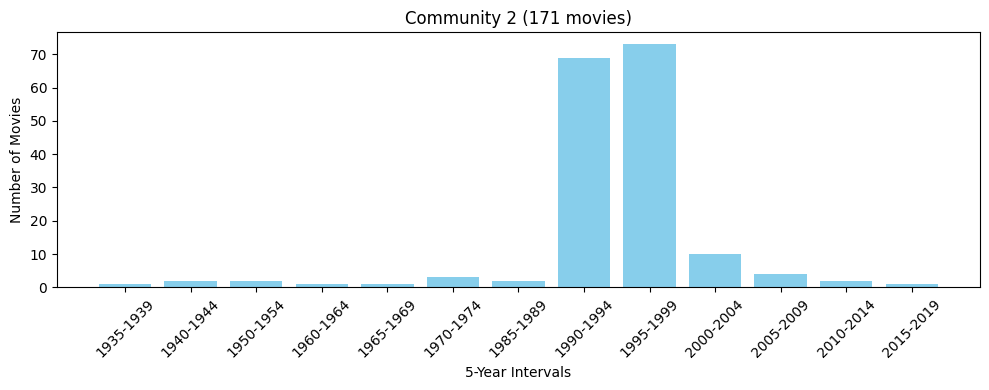

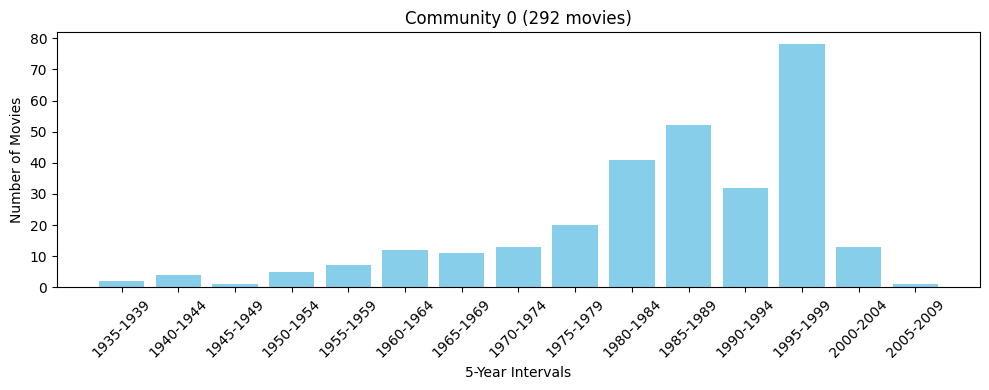

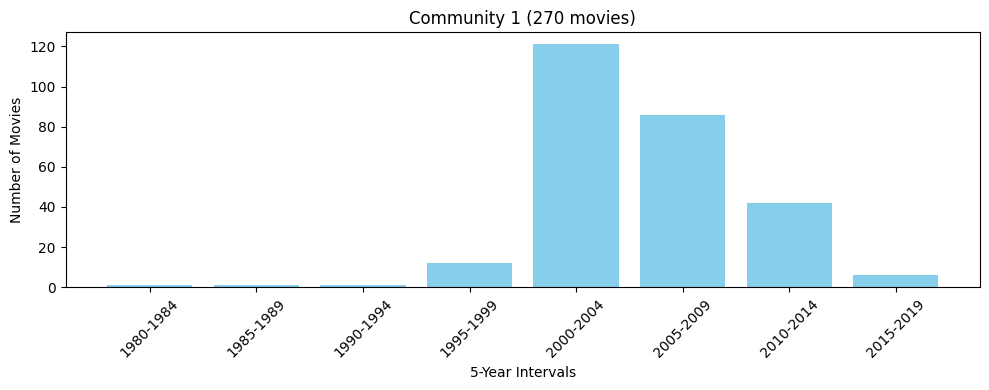

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# Function to count release years in 5-year bins per community
def analyze_year_bins_per_community(df, bin_size=5):
    community_year_bins = {}

    for community_id in df['modularity_Class'].unique():
        community_movies = df[df['modularity_Class'] == community_id]
        year_list = []
        for year in community_movies['year']:
            if pd.notna(year):
                try:
                    year = int(year)
                    binned_year = (year // bin_size) * bin_size
                    year_list.append(binned_year)
                except ValueError:
                    pass
        year_bin_counts = Counter(year_list)
        community_year_bins[community_id] = year_bin_counts

    return community_year_bins
# Analyze the data
community_year_bins = analyze_year_bins_per_community(merged_df)

# Plot for each community
for community_id, year_bin_counts in community_year_bins.items():
    years = sorted(year_bin_counts.keys())
    counts = [year_bin_counts[year] for year in years]

    plt.figure(figsize=(10, 4))
    plt.bar([f"{year}-{year+4}" for year in years], counts, color='skyblue')
    plt.title(f"Community {community_id} ({len(merged_df[merged_df['modularity_Class'] == community_id])} movies)")
    plt.xlabel("5-Year Intervals")
    plt.ylabel("Number of Movies")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()



Results

In [ ]:
for community_id, year_counts in community_years.items():
    total_movies = sum(year_counts.values())
    if total_movies > 0:
        most_common_year, count = year_counts.most_common(1)[0]
        purity = count / total_movies
        print(f"Community {community_id}: Most common year = {most_common_year} ({purity:.2%})")


Community 2: Most common year = 1995 (25.15%)
Community 0: Most common year = 1998 (7.88%)
Community 1: Most common year = 2004 (11.48%)


Analyzing genres in communties based on inference class

In [ ]:
from collections import Counter

# Function to split genres and count them per community
def analyze_genres_per_community(df):
    # Create a dictionary to store genre counts per community
    community_genres = {}

    # Iterate over each community
    for community_id in df['stat_inf_class'].unique():
        # Filter movies in this community
        community_movies = df[df['stat_inf_class'] == community_id]
        # Split genres and flatten the list
        genres_list = []
        for genres in community_movies['genres']:
            if pd.notna(genres) and genres != '(no genres listed)':
                genres_list.extend(genres.split('|'))
        # Count genre occurrences
        genre_counts = Counter(genres_list)
        community_genres[community_id] = genre_counts

    return community_genres

# Run the analysis
community_genres = analyze_genres_per_community(merged_df)

# Print results
for community_id, genre_counts in community_genres.items():
    print(f"Community {community_id} ({len(merged_df[merged_df['stat_inf_class'] == community_id])} movies):")
    print(genre_counts.most_common())
    print()

Community 8 (1 movies):
[('Adventure', 1), ('Animation', 1), ('Children', 1), ('Comedy', 1), ('Fantasy', 1)]

Community 21 (15 movies):
[('Comedy', 9), ('Children', 6), ('Fantasy', 6), ('Musical', 6), ('Drama', 4), ('Adventure', 3), ('Romance', 3), ('Animation', 2), ('Action', 1), ('Crime', 1)]

Community 29 (2 movies):
[('Action', 2), ('Crime', 2), ('Thriller', 2), ('Drama', 1)]

Community 9 (8 movies):
[('Thriller', 6), ('Drama', 5), ('Action', 4), ('Adventure', 4), ('Romance', 2), ('Comedy', 1), ('IMAX', 1), ('War', 1), ('Crime', 1), ('Sci-Fi', 1)]

Community 28 (3 movies):
[('Drama', 2), ('Crime', 1), ('Action', 1), ('Comedy', 1), ('Musical', 1), ('War', 1)]

Community 14 (12 movies):
[('Comedy', 5), ('Thriller', 5), ('Drama', 5), ('Romance', 5), ('Action', 4), ('Sci-Fi', 2), ('Fantasy', 2), ('Crime', 1), ('Adventure', 1), ('Western', 1), ('Animation', 1), ('Children', 1), ('Musical', 1), ('IMAX', 1)]

Community 1 (4 movies):
[('Thriller', 2), ('Drama', 1), ('Romance', 1), ('Myster

In [9]:
from collections import Counter

# Function to count release years per stat_inf_class community
def analyze_years_per_stat_inf_class(df):
    # Dictionary to store year counts per community
    community_years = {}

    # Iterate over each community in stat_inf_class
    for community_id in df['stat_inf_Class'].unique():
        # Filter movies in this community
        community_movies = df[df['stat_inf_Class'] == community_id]
        # Extract valid years
        year_list = []
        for year in community_movies['year']:
            if pd.notna(year):
                try:
                    year_list.append(int(year))
                except ValueError:
                    pass  # Skip non-integer years if any
        # Count year occurrences
        year_counts = Counter(year_list)
        community_years[community_id] = year_counts

    return community_years

# Run the analysis
community_years_stat_inf = analyze_years_per_stat_inf_class(merged_df)

# Print results
for community_id, year_counts in community_years_stat_inf.items():
    print(f"Community {community_id} ({len(merged_df[merged_df['stat_inf_Class'] == community_id])} movies):")
    print(year_counts.most_common(10))  # Top 10 years
    print()


Community 186 (1 movies):
[(1995, 1)]

Community 50 (17 movies):
[(2004, 3), (1999, 2), (1951, 1), (1942, 1), (1993, 1), (2011, 1), (2009, 1), (2007, 1), (1997, 1), (1964, 1)]

Community 16 (1 movies):
[(1971, 1)]

Community 166 (2 movies):
[(1979, 1), (1985, 1)]

Community 65 (1 movies):
[(1992, 1)]

Community 13 (5 movies):
[(1986, 1), (1994, 1), (1992, 1), (1997, 1), (1987, 1)]

Community 67 (3 movies):
[(1982, 1), (1992, 1), (1984, 1)]

Community 91 (1 movies):
[(1995, 1)]

Community 34 (3 movies):
[(1989, 1), (1982, 1), (1987, 1)]

Community 209 (2 movies):
[(1975, 1), (1971, 1)]

Community 20 (1 movies):
[(1980, 1)]

Community 219 (1 movies):
[(1987, 1)]

Community 69 (2 movies):
[(1981, 1), (1991, 1)]

Community 176 (1 movies):
[(1971, 1)]

Community 66 (3 movies):
[(1979, 2), (1983, 1)]

Community 68 (2 movies):
[(1983, 1), (1998, 1)]

Community 106 (1 movies):
[(1990, 1)]

Community 143 (1 movies):
[(1979, 1)]

Community 2 (2 movies):
[(1980, 1), (1987, 1)]

Community 115 (2 m

In [10]:
# Print most common year and purity for each stat_inf_Class
for community_id, year_counts in community_years_stat_inf.items():
    total_movies = sum(year_counts.values())
    if total_movies > 0:
        most_common_year, count = year_counts.most_common(1)[0]
        purity = count / total_movies
        print(f"Community {community_id}: Most common year = {most_common_year} ({purity:.2%})")


Community 186: Most common year = 1995 (100.00%)
Community 50: Most common year = 2004 (17.65%)
Community 16: Most common year = 1971 (100.00%)
Community 166: Most common year = 1979 (50.00%)
Community 65: Most common year = 1992 (100.00%)
Community 13: Most common year = 1986 (20.00%)
Community 67: Most common year = 1982 (33.33%)
Community 91: Most common year = 1995 (100.00%)
Community 34: Most common year = 1989 (33.33%)
Community 209: Most common year = 1975 (50.00%)
Community 20: Most common year = 1980 (100.00%)
Community 219: Most common year = 1987 (100.00%)
Community 69: Most common year = 1981 (50.00%)
Community 176: Most common year = 1971 (100.00%)
Community 66: Most common year = 1979 (66.67%)
Community 68: Most common year = 1983 (50.00%)
Community 106: Most common year = 1990 (100.00%)
Community 143: Most common year = 1979 (100.00%)
Community 2: Most common year = 1980 (50.00%)
Community 115: Most common year = 1987 (50.00%)
Community 210: Most common year = 1984 (100.

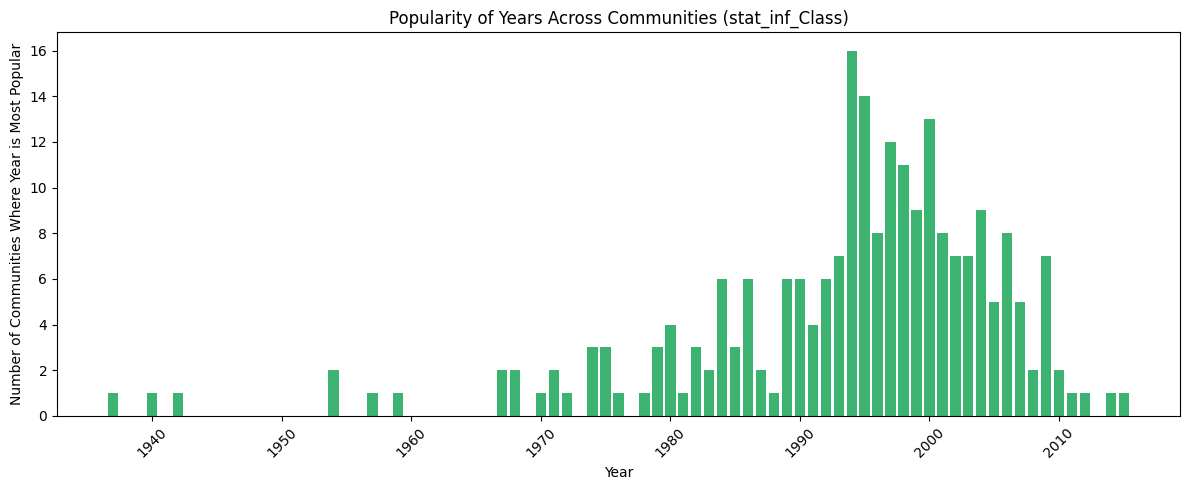

In [11]:
import matplotlib.pyplot as plt
from collections import Counter

# Count how many times each year is the most popular across communities
popular_years_across_communities = Counter()

for year_counts in community_years_stat_inf.values():
    if year_counts:
        most_common_year, _ = year_counts.most_common(1)[0]
        popular_years_across_communities[most_common_year] += 1

# Sort years
years = sorted(popular_years_across_communities.keys())
counts = [popular_years_across_communities[year] for year in years]

# Plot
plt.figure(figsize=(12, 5))
plt.bar(years, counts, color='mediumseagreen')
plt.xlabel("Year")
plt.ylabel("Number of Communities Where Year is Most Popular")
plt.title("Popularity of Years Across Communities (stat_inf_Class)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [19]:
from collections import Counter

# Define the range of years
year_range = range(1990, 2006)

# Iterate over each year
for target_year in year_range:
    print(f"\n--- Popular Genres for Year {target_year} ---")

    # Step 1: For each community, check if the target year is the most common year
    for community_id, year_counts in community_years_stat_inf.items():
        if not year_counts:
            continue

        most_common_year, _ = year_counts.most_common(1)[0]

        # Step 2: If target year is the most common year for this community
        if most_common_year == target_year:
            print(f"\nCommunity {community_id}:")

            # Step 3: Filter movies in this community for the target year
            community_movies = merged_df[
                (merged_df['stat_inf_Class'] == community_id) &
                (merged_df['year'] == target_year)
            ]

            # Step 4: Count genres for these movies
            genre_counter = Counter()
            for genres in community_movies['genres']:
                if pd.notna(genres):
                    genre_list = [g.strip() for g in genres.split(',') if g.strip()]
                    genre_counter.update(genre_list)

            # Step 5: Find the most common genre for this community in the target year
            if genre_counter:
                most_common_genre, count = genre_counter.most_common(1)[0]
                print(f"  Most Common Genre: {most_common_genre} with {count} movies")
            else:
                print("  No genres found for this community in the given year.")



--- Popular Genres for Year 1990 ---

Community 106:
  Most Common Genre: Crime|Drama with 1 movies

Community 104:
  Most Common Genre: Adventure|Comedy|Sci-Fi|Western with 1 movies

Community 35:
  Most Common Genre: Drama|Fantasy|Romance with 1 movies

Community 169:
  Most Common Genre: Action|Adventure|Sci-Fi|Thriller with 1 movies

Community 178:
  Most Common Genre: Comedy|Romance with 1 movies

Community 59:
  Most Common Genre: Action|Adventure|Thriller with 1 movies

--- Popular Genres for Year 1991 ---

Community 196:
  Most Common Genre: Adventure|Comedy|Fantasy with 1 movies

Community 101:
  Most Common Genre: Crime|Horror|Thriller with 1 movies

Community 86:
  Most Common Genre: Animation|Children|Fantasy|Musical|Romance|IMAX with 1 movies

Community 38:
  Most Common Genre: Action|Sci-Fi with 1 movies

--- Popular Genres for Year 1992 ---

Community 65:
  Most Common Genre: Crime|Mystery|Thriller with 1 movies

Community 180:
  Most Common Genre: Action|Crime with 1 m

In [15]:
from collections import Counter

# Define the year of interest
target_year = 1999

# Step 1: Find communities where the most common year is the target year
matching_communities = [
    community_id
    for community_id, year_counts in community_years_stat_inf.items()
    if year_counts and year_counts.most_common(1)[0][0] == target_year
]

print(f"Communities with most common year = {target_year}: {matching_communities}")

# Step 2: Collect all movies from those communities that were released in that year
movies_in_target_year = merged_df[
    (merged_df['stat_inf_Class'].isin(matching_communities)) &
    (merged_df['year'] == target_year)
]

# Step 3: Count genres from these movies
genre_counts = Counter()

for genres in movies_in_target_year['genres']:
    if pd.notna(genres):
        genre_list = [g.strip() for g in genres.split(',') if g.strip()]
        genre_counts.update(genre_list)

# Step 4: Display the genre counts (excluding zero-counts, naturally)
print(f"\nGenre distribution for movies released in {target_year} from matched communities:")
for genre, count in genre_counts.most_common():
    print(f"{genre}: {count}")


Communities with most common year = 1999: [np.int64(22), np.int64(114), np.int64(40), np.int64(51), np.int64(46), np.int64(182), np.int64(37), np.int64(225), np.int64(217)]

Genre distribution for movies released in 1999 from matched communities:
Comedy|Crime: 2
Comedy: 2
Action|Sci-Fi|Thriller: 1
Drama|Romance: 1
Action|Crime|Drama|Thriller: 1
Comedy|Drama|Fantasy: 1
Adventure|Comedy|Fantasy: 1
Crime|Drama: 1
Drama|Horror|Mystery: 1
Action|Thriller: 1
Comedy|Drama: 1
Comedy|Romance: 1
Action|Adventure|Thriller: 1


In [14]:
# Step 1: Loop over communities and process only those with most common year between 1990 and 2005
for community_id, year_counts in community_years_stat_inf.items():
    if not year_counts:
        continue

    most_common_year, _ = year_counts.most_common(1)[0]

    if 1990 <= most_common_year <= 2005:
        print(f"\nCommunity {community_id} - Most Popular Year: {most_common_year}")

        # Filter to movies in this community from the most popular year
        community_movies = merged_df[
            (merged_df['stat_inf_Class'] == community_id) &
            (merged_df['year'] == most_common_year)
        ]

        # Print popular movie titles
        print("Popular Movies:")
        for title in community_movies['title']:
            print(f"  - {title}")

        # Count genres in the entire community (not just most common year)
        genre_counts = Counter()
        all_community_movies = merged_df[merged_df['stat_inf_Class'] == community_id]

        for genres in all_community_movies['genres']:
            if pd.notna(genres):
                genre_list = [g.strip() for g in genres.split(',') if g.strip()]
                genre_counts.update(genre_list)

        # Print non-zero genre counts
        print("Genres in Community:")
        for genre, count in genre_counts.items():
            if count > 0:
                print(f"  {genre}: {count}")



Community 186 - Most Popular Year: 1995
Popular Movies:
  - Toy Story (1995)
Genres in Community:
  Adventure|Animation|Children|Comedy|Fantasy: 1

Community 50 - Most Popular Year: 2004
Popular Movies:
  - Aviator, The (2004)
  - National Treasure (2004)
  - Napoleon Dynamite (2004)
Genres in Community:
  Adventure|Animation|Children|Fantasy|Musical: 1
  Animation|Children|Drama: 1
  Comedy|Drama: 2
  Drama: 1
  Comedy|Drama|Romance: 3
  Drama|Horror|Musical|Thriller: 1
  Comedy|Romance: 1
  Comedy|Drama|Musical|Romance: 1
  Comedy: 4
  Action|Adventure|Drama|Mystery|Thriller: 1
  Drama|Horror|Thriller: 1

Community 65 - Most Popular Year: 1992
Popular Movies:
  - Reservoir Dogs (1992)
Genres in Community:
  Crime|Mystery|Thriller: 1

Community 91 - Most Popular Year: 1995
Popular Movies:
  - Braveheart (1995)
Genres in Community:
  Action|Drama|War: 1

Community 106 - Most Popular Year: 1990
Popular Movies:
  - Goodfellas (1990)
Genres in Community:
  Crime|Drama: 1

Community 4 - M

Broader classification of genres

In [ ]:
#inf class results
import pandas as pd
from collections import Counter

genre_mapping = {
    'Action': 'Action',
    'Adventure': 'Action',
    'Sci-Fi': 'Thriller',
    'Thriller': 'Thriller',
    'War': 'Action',
    'Comedy': 'Comedy',
    'Children\'s': 'Animation',
    'Animation': 'Animation',
    'Musical': 'Romance',
    'Romance': 'Romance',
    'Drama': 'Drama',
    'Crime': 'Crime',
    'Mystery': 'Thriller',
    'Film-Noir': 'Crime',
    'Western': 'Drama',
    'Fantasy': 'Animation',
    'Horror': 'Horror',
    'Documentary': 'Other',
    '(no genres listed)': 'Other'
}

# Load and merge data
nodes_df = pd.read_csv('community_detection.csv')
nodes_df['movieId'] = nodes_df['Id']
movies_df = pd.read_csv('movies.csv')
movies_df['movieId'] = movies_df['movieId'].astype(int)
merged_df = pd.merge(nodes_df, movies_df, on='movieId', how='inner')
merged_df.to_csv('movies_with_communities.csv', index=False)

# Function to map genres to broad categories and analyze per community
def analyze_broad_genres_per_community(df):
    community_genres = {}

    for community_id in df['stat_inf_class'].unique():
        community_movies = df[df['stat_inf_class'] == community_id]
        broad_genres_list = []

        # Process each movie's genres
        for genres in community_movies['genres']:
            if pd.notna(genres) and genres != '(no genres listed)':
                sub_genres = genres.split('|')
                # Map each sub-genre to its broad category
                for sub_genre in sub_genres:
                    broad_genre = genre_mapping.get(sub_genre, 'Other')
                    broad_genres_list.append(broad_genre)
            else:
                broad_genres_list.append('Other')

        # Count broad genres
        genre_counts = Counter(broad_genres_list)
        community_genres[community_id] = genre_counts

    return community_genres

# Run analysis
community_genres = analyze_broad_genres_per_community(merged_df)

# Print results
for community_id, genre_counts in community_genres.items():
    total_genres = sum(genre_counts.values())
    print(f"Community {community_id} ({len(merged_df[merged_df['stat_inf_class'] == community_id])} movies):")
    for genre, count in genre_counts.most_common():
        print(f"  {genre}: {count} ({count/total_genres:.2%})")
    print()

# Verify the merge
print("Merged Data Preview:")
print(merged_df[['movieId', 'title', 'genres', 'stat_inf_class']].head())

Community 8 (1 movies):
  Animation: 2 (40.00%)
  Action: 1 (20.00%)
  Other: 1 (20.00%)
  Comedy: 1 (20.00%)

Community 21 (15 movies):
  Comedy: 9 (21.95%)
  Romance: 9 (21.95%)
  Animation: 8 (19.51%)
  Other: 6 (14.63%)
  Action: 4 (9.76%)
  Drama: 4 (9.76%)
  Crime: 1 (2.44%)

Community 29 (2 movies):
  Action: 2 (28.57%)
  Crime: 2 (28.57%)
  Thriller: 2 (28.57%)
  Drama: 1 (14.29%)

Community 9 (8 movies):
  Action: 9 (34.62%)
  Thriller: 7 (26.92%)
  Drama: 5 (19.23%)
  Romance: 2 (7.69%)
  Comedy: 1 (3.85%)
  Other: 1 (3.85%)
  Crime: 1 (3.85%)

Community 28 (3 movies):
  Drama: 2 (28.57%)
  Action: 2 (28.57%)
  Crime: 1 (14.29%)
  Comedy: 1 (14.29%)
  Romance: 1 (14.29%)

Community 14 (12 movies):
  Thriller: 7 (20.00%)
  Drama: 6 (17.14%)
  Romance: 6 (17.14%)
  Comedy: 5 (14.29%)
  Action: 5 (14.29%)
  Animation: 3 (8.57%)
  Other: 2 (5.71%)
  Crime: 1 (2.86%)

Community 1 (4 movies):
  Thriller: 4 (44.44%)
  Action: 2 (22.22%)
  Drama: 1 (11.11%)
  Romance: 1 (11.11%)
  Co

In [ ]:
# modularity_class results
nodes_df = pd.read_csv('community_detection.csv')
nodes_df['movieId'] = nodes_df['Id']
movies_df = pd.read_csv('movies.csv')
movies_df['movieId'] = movies_df['movieId'].astype(int)
merged_df = pd.merge(nodes_df, movies_df, on='movieId', how='inner')
merged_df.to_csv('movies_with_communities.csv', index=False)

# Function to map genres to broad categories and analyze per community
def analyze_broad_genres_per_community(df):
    community_genres = {}

    for community_id in df['modularity_class'].unique():
        community_movies = df[df['modularity_class'] == community_id]
        broad_genres_list = []

        # Process each movie's genres
        for genres in community_movies['genres']:
            if pd.notna(genres) and genres != '(no genres listed)':
                sub_genres = genres.split('|')
                # Map each sub-genre to its broad category
                for sub_genre in sub_genres:
                    broad_genre = genre_mapping.get(sub_genre, 'Other')
                    broad_genres_list.append(broad_genre)
            else:
                broad_genres_list.append('Other')

        # Count broad genres
        genre_counts = Counter(broad_genres_list)
        community_genres[community_id] = genre_counts

    return community_genres

# Run analysis
community_genres = analyze_broad_genres_per_community(merged_df)

# Print results
for community_id, genre_counts in community_genres.items():
    total_genres = sum(genre_counts.values())
    print(f"Community {community_id} ({len(merged_df[merged_df['modularity_class'] == community_id])} movies):")
    for genre, count in genre_counts.most_common():
        print(f"  {genre}: {count} ({count/total_genres:.2%})")
    print()

# Verify the merge
print("Merged Data Preview:")
print(merged_df[['movieId', 'title', 'genres', 'modularity_class']].head())

Community 1 (99 movies):
  Action/Adventure: 95 (34.17%)
  Drama/Serious: 88 (31.65%)
  Comedy/Light: 63 (22.66%)
  Other: 15 (5.40%)
  Fantasy/Imaginative: 11 (3.96%)
  Horror: 6 (2.16%)

Community 0 (80 movies):
  Drama/Serious: 75 (36.23%)
  Action/Adventure: 66 (31.88%)
  Comedy/Light: 44 (21.26%)
  Fantasy/Imaginative: 10 (4.83%)
  Other: 6 (2.90%)
  Horror: 6 (2.90%)

Community 3 (96 movies):
  Action/Adventure: 145 (44.62%)
  Drama/Serious: 79 (24.31%)
  Comedy/Light: 50 (15.38%)
  Other: 28 (8.62%)
  Fantasy/Imaginative: 20 (6.15%)
  Horror: 3 (0.92%)

Community 2 (56 movies):
  Action/Adventure: 90 (57.69%)
  Comedy/Light: 32 (20.51%)
  Drama/Serious: 27 (17.31%)
  Other: 4 (2.56%)
  Fantasy/Imaginative: 3 (1.92%)

Community 4 (3 movies):
  Action/Adventure: 5 (33.33%)
  Fantasy/Imaginative: 3 (20.00%)
  Drama/Serious: 3 (20.00%)
  Other: 3 (20.00%)
  Comedy/Light: 1 (6.67%)

Merged Data Preview:
   movieId                           title  \
0        1                Toy Story